# Colab Setup

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
import matplotlib.pyplot as plt
import numpy as np

: 

# Dataset Importing

In [ ]:
# Install KaggleHub
!pip install kagglehub

# Import library
import kagglehub
import os

# Download latest version of dataset
path = kagglehub.dataset_download("elmadafri/the-wildfire-dataset")

# Show dataset path
print("Path to dataset files:", path)

# List files/folders inside dataset
print("\nDataset Content:\n")
print(os.listdir(path))

Using Colab cache for faster access to the 'the-wildfire-dataset' dataset.
Path to dataset files: /kaggle/input/the-wildfire-dataset

Dataset Content:

['the_wildfire_dataset_2n_version']


In [ ]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])  # first 5 files
    print("-"*50)

Folder: /kaggle/input/the-wildfire-dataset
Subfolders: ['the_wildfire_dataset_2n_version']
Files: []
--------------------------------------------------
Folder: /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version
Subfolders: ['val', 'test', 'train']
Files: []
--------------------------------------------------
Folder: /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/val
Subfolders: ['nofire', 'fire']
Files: []
--------------------------------------------------
Folder: /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire
Subfolders: []
Files: ['ashton-morris-cEn0ztKTjes-unsplash.jpg', 'elena-mozhvilo-tvDuKySFy_o-unsplash.jpg', 'kristaps-ungurs-TlJSzJlPRc8-unsplash.jpg', 'nitish-meena-ytGtKR94nAI-unsplash.jpg', 'guillaume-bourdages-VKMx4lonuLg-unsplash.jpg']
--------------------------------------------------
Folder: /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/fire
Subfolders: []
Files: ['50747827342_6e6ccb

In [ ]:
import os
import shutil

# The 'path' variable is defined in cell C89NNkvunqaF
# It points to '/kaggle/input/the-wildfire-dataset'
# From the os.walk output, the actual dataset is in a subdirectory.
source_dataset_root = os.path.join(path, 'the_wildfire_dataset_2n_version')
destination_dataset_root = '/content/the_wildfire_dataset_2n_version'

# Remove destination directory if it already exists to avoid errors during copy
if os.path.exists(destination_dataset_root):
    print(f"Removing existing directory: {destination_dataset_root}")
    shutil.rmtree(destination_dataset_root)

print(f"Copying dataset from {source_dataset_root} to {destination_dataset_root}")
shutil.copytree(source_dataset_root, destination_dataset_root)
print("Dataset copied successfully.")

# Define dataset_path for ImageDataGenerator
dataset_path = destination_dataset_root
print(f"Dataset path for ImageDataGenerator set to: {dataset_path}")

Copying dataset from /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version to /content/the_wildfire_dataset_2n_version
Dataset copied successfully.
Dataset path for ImageDataGenerator set to: /content/the_wildfire_dataset_2n_version


# Data Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
IMG_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 32

# Advanced Augmentation
train_datagen = ImageDataGenerator(

    # Normalize images
    rescale=1./255,

    # Rotation
    rotation_range=30,

    # Shift image horizontally
    width_shift_range=0.2,

    # Shift image vertically
    height_shift_range=0.2,

    # Zoom augmentation
    zoom_range=0.3,

    # Shear transformation
    shear_range=0.2,

    # Horizontal flip
    horizontal_flip=True,

    # Brightness adjustment
    brightness_range=[0.8,1.2],

    # Fill missing pixels
    fill_mode='nearest',

    # Validation split
    validation_split=0.2
)

# Validation generator
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training Data
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation Data
val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# Show class labels
print("Class Labels:")
print(train_data.class_indices)

Found 2160 images belonging to 3 classes.
Found 539 images belonging to 3 classes.
Class Labels:
{'test': 0, 'train': 1, 'val': 2}


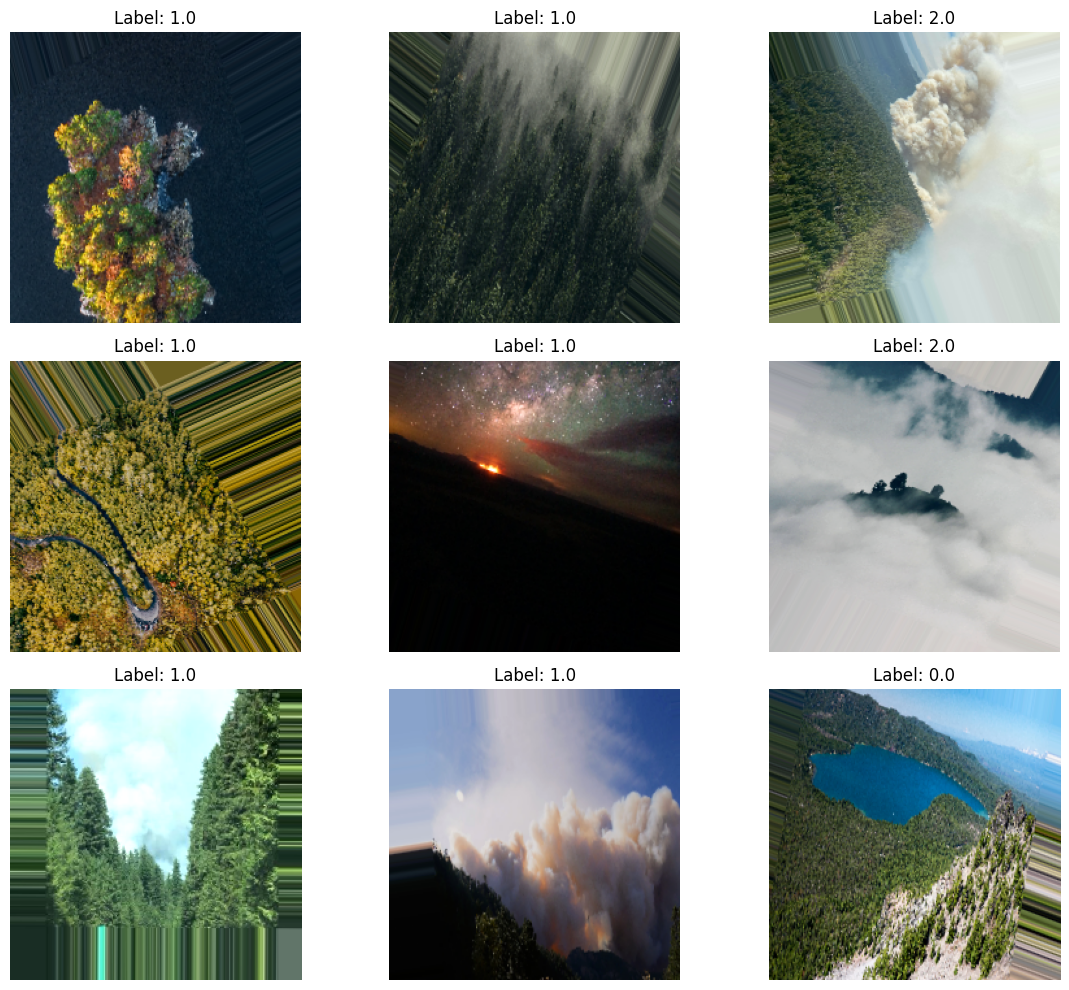

In [ ]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(train_data)

# Plot augmented images
plt.figure(figsize=(12,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
rescale=1./255

# Models

**Custom CNN Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# CNN Model
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
 4/68 ━━━━━━━━━━━━━━━━━━━━ 12:32 12s/step - accuracy: 0.6543 - loss: -0.0873

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 7/68 ━━━━━━━━━━━━━━━━━━━━ 12:48 13s/step - accuracy: 0.6592 - loss: -0.9621

KeyboardInterrupt: 

**VGG16 Tranfer Learning**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load pretrained VGG16
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
vgg_base.trainable = False

# Build model
vgg_model = Sequential([
    vgg_base,

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
vgg_model.summary()

In [ ]:
vgg_history = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
resnet_base.trainable = False

# Build model
resnet_model = Sequential([
    resnet_base,

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
resnet_model.summary()

In [ ]:
resnet_history = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2
mobile_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
mobile_base.trainable = False

# Build model
mobile_model = Sequential([
    mobile_base,

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile
mobile_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
mobile_model.summary()

In [ ]:
mobile_history = mobile_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# Compare Accuracies

In [ ]:
print("CNN Accuracy:", max(cnn_history.history['val_accuracy']))
print("VGG16 Accuracy:", max(vgg_history.history['val_accuracy']))
print("ResNet50 Accuracy:", max(resnet_history.history['val_accuracy']))
print("MobileNetV2 Accuracy:", max(mobile_history.history['val_accuracy']))

# Accuracy Graph

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(vgg_history.history['val_accuracy'], label='VGG16')
plt.plot(resnet_history.history['val_accuracy'], label='ResNet50')
plt.plot(mobile_history.history['val_accuracy'], label='MobileNetV2')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.show()